In [7]:
import numpy as np
import xarray as xr
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# 1. Get the path of the parent directory (my_project)
parent_dir = str(Path().resolve().parent)
# 2. Append it to sys.path if it isn't already there
if parent_dir not in sys.path:
    sys.path.append(parent_dir)

# 3. Import wave_forcing functions
import src.wave_forcing as wf


In [6]:
equator_bounds = [-5, 5, 210, 220]
hs = 2.5
#fp = 0.1
period_list = [5, 10, 15]
#period_list=[10]
for period in period_list:
    fp = 1/period
    #print(fp)
    save_path = "/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/BCs_s5/BC_"+str(period)
    #wf.save_steady_waves(equator_bounds, hs, fp, save_path, s=5)


2.487903414086448
[ 90.  75.  60.  45.  30.  15.   0. 345. 330. 315. 300. 285. 270. 255.
 240. 225. 210. 195. 180. 165. 150. 135. 120. 105.]
<xarray.DataArray 'direction' (direction: 24)>
array([ 90.,  75.,  60.,  45.,  30.,  15.,   0., 345., 330., 315., 300., 285.,
       270., 255., 240., 225., 210., 195., 180., 165., 150., 135., 120., 105.],
      dtype=float32)
Coordinates:
  * direction  (direction) float32 90.0 75.0 60.0 45.0 ... 135.0 120.0 105.0
Attributes:
    long_name:      sea surface wave to direction
    standard_name:  sea_surface_wave_to_direction
    globwave_name:  direction
    units:          degree
    valid_min:      0.0
    valid_max:      360.0
    axis:           Z
2.50101591933524
[ 90.  75.  60.  45.  30.  15.   0. 345. 330. 315. 300. 285. 270. 255.
 240. 225. 210. 195. 180. 165. 150. 135. 120. 105.]
<xarray.DataArray 'direction' (direction: 24)>
array([ 90.,  75.,  60.,  45.,  30.,  15.,   0., 345., 330., 315., 300., 285.,
       270., 255., 240., 225., 210.

Text(0.5, 1.0, '1D Energy Density spectrum')

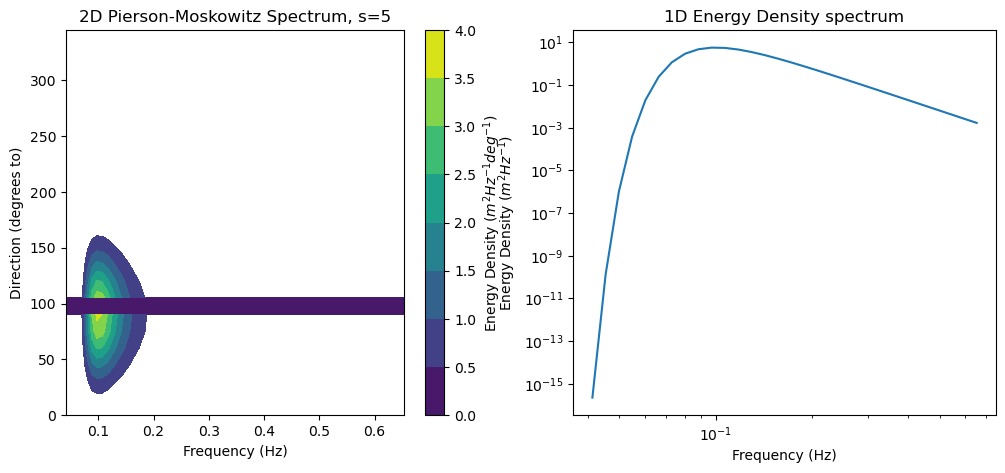

In [8]:
#Plot example 
f0 = 0.04118
f = np.zeros(30)
f[0] = f0
xfr = 1.1
for ind in range(1, len(f)):
    f[ind] = f[ind-1]*1.1
directions = (np.pi/180)*np.array([90.,  75.,  60.,  45.,  30.,  15.,   0., 345., 330., 315., 300., 285.,
       270., 255., 240., 225., 210., 195., 180., 165., 150., 135., 120., 105.])  # degrees

f, Sf = wf.pm_spectrum(f, 1/10, 2.5)
theta_0 = np.pi/2
s=5
# Directional Spreading Function (normalized)
F, Theta, S_f_theta = wf.dir_spreading(directions, f, theta_0, Sf, s=s)

fig, ax = plt.subplots(1,2, figsize=(12, 5))
cm0 = ax[0].contourf(F, Theta*180/np.pi, S_f_theta, cmap='viridis')
plt.colorbar(cm0, label='Energy Density ($m^2Hz^{-1}deg^{-1}$)')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Direction (degrees to)')
ax[0].set_title('2D Pierson-Moskowitz Spectrum, s='+str(s))
#plt.yticklabels([0, 20, 40, 60, 80, 100, 120, 140, 160, 180])

#ax[0].set_ylim(180, 360)


ax[1].loglog(f, Sf)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Energy Density ($m^2Hz^{-1}$)")
ax[1].set_title("1D Energy Density spectrum")
#ax[1].set_ylim(0.0000001, 10**-2)
#plt.plot(S_f_theta[


Text(0.5, 1.0, '1D Energy Density spectrum')

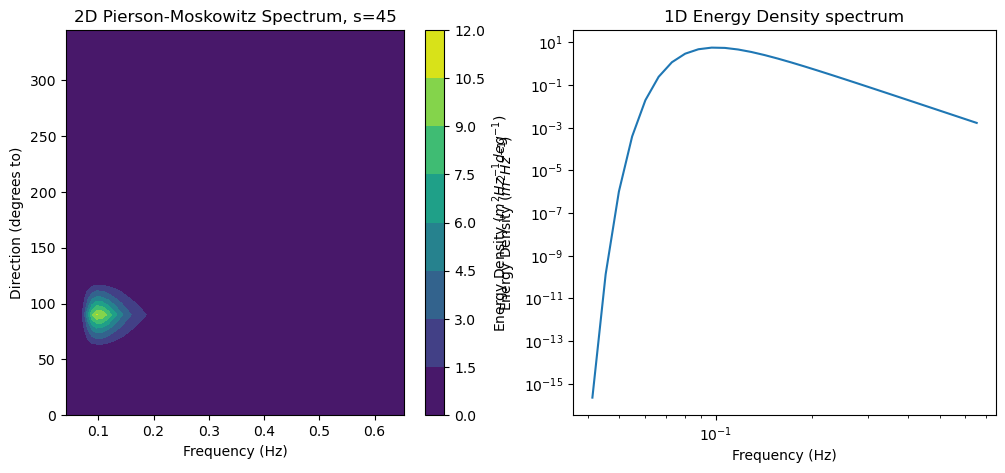

In [3]:
#Plot example 
f0 = 0.04118
f = np.zeros(30)
f[0] = f0
xfr = 1.1
for ind in range(1, len(f)):
    f[ind] = f[ind-1]*1.1
directions = (np.pi/180)*np.array([90.,  75.,  60.,  45.,  30.,  15.,   0., 345., 330., 315., 300., 285.,
       270., 255., 240., 225., 210., 195., 180., 165., 150., 135., 120., 105.])  # degrees

directions= np.sort(directions)

f, Sf = wf.pm_spectrum(f, 1/10, 2.5)
theta_0 = np.pi/2
s=45
# Directional Spreading Function (normalized)
F, Theta, S_f_theta = wf.dir_spreading(directions, f, theta_0, Sf, s=s)

fig, ax = plt.subplots(1,2, figsize=(12, 5))
cm0 = ax[0].contourf(F, Theta*180/np.pi, S_f_theta, cmap='viridis')
plt.colorbar(cm0, label='Energy Density ($m^2Hz^{-1}deg^{-1}$)')
ax[0].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Direction (degrees to)')
ax[0].set_title('2D Pierson-Moskowitz Spectrum, s='+str(s))
#plt.yticklabels([0, 20, 40, 60, 80, 100, 120, 140, 160, 180])

#ax[0].set_ylim(180, 360)


ax[1].loglog(f, Sf)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Energy Density ($m^2Hz^{-1}$)")
ax[1].set_title("1D Energy Density spectrum")
#ax[1].set_ylim(0.0000001, 10**-2)
#plt.plot(S_f_theta[


In [58]:
cs = wf.dir_normalization_coeff(directions, np.pi/2, 20)

np.trapz(np.cos((np.sort(directions)-(np.pi/2))/2)**(2*20), np.sort(directions))

0.7877271372541845

In [60]:
dir_sort = np.sort(directions) # Sort
theta_0 = np.pi/2
s=20
cs*np.trapz(np.cos((dir_sort-theta_0)/2)**(2*s), dir_sort)


1.0

In [37]:
4*np.sqrt(np.trapz(np.trapz(S_f_theta, Theta, axis=0), F[0, :]))

2.50101591933524

array([0.04118   , 0.045298  , 0.0498278 , 0.05481058, 0.06029164,
       0.0663208 , 0.07295288, 0.08024817, 0.08827299, 0.09710029,
       0.10681031, 0.11749135, 0.12924048, 0.14216453, 0.15638098,
       0.17201908, 0.18922099, 0.20814309, 0.22895739, 0.25185313,
       0.27703845, 0.30474229, 0.33521652, 0.36873817, 0.40561199,
       0.44617319, 0.49079051, 0.53986956, 0.59385652, 0.65324217])

In [4]:
#Test to make sure that saved specs have right Hs
spec = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/BCs_s45/BC_10/boundary_spec_bottom_0.nc")

spec_mod = spec.sortby('direction')
hs = 4*np.sqrt(np.trapz(np.trapz(spec_mod.efth[10, 0, :, :].squeeze(), (np.pi/180)*spec_mod.direction, axis=1), spec_mod.frequency))
print(hs)


2.5010159547387656


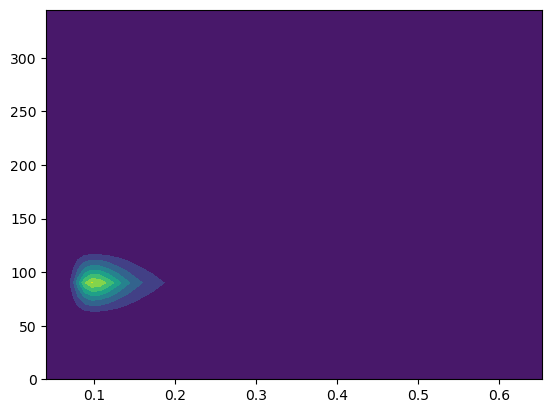

In [22]:
plt.contourf(F, 180*Theta/np.pi, S_f_theta)

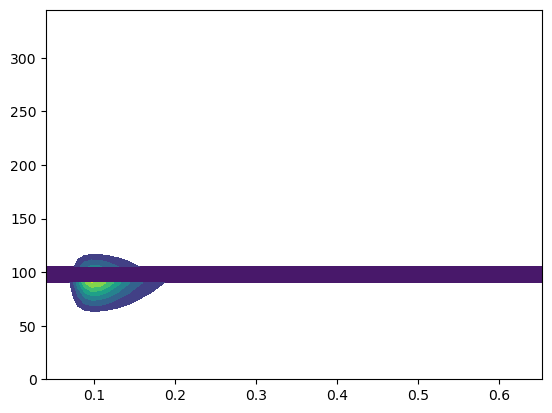

In [10]:
plt.contourf(spec.frequency, spec.direction, spec.efth[10, 0, :, :].T)


2.50101591933524
2.5010159547387656


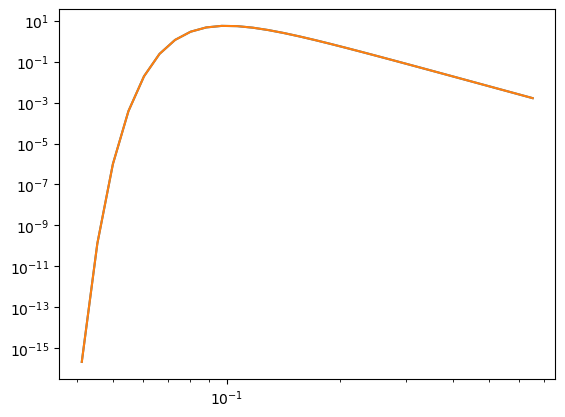

In [5]:
Sf_calc = np.trapz(spec_mod.efth[10, :, :].squeeze(), (np.pi/180)*spec_mod.direction, axis=1)
#Sf_calc2 = np.trapz(S_f_theta, Theta, axis=0)
plt.loglog(f, Sf)
plt.loglog(spec.frequency, Sf_calc)
#plt.loglog(F[0, :], Sf_calc2)
print(4*np.sqrt(np.trapz(Sf, f)))
print(4*np.sqrt(np.trapz(Sf_calc, spec_mod.frequency)))


In [24]:
print(f)

[0.04118    0.045298   0.0498278  0.05481058 0.06029164 0.0663208
 0.07295288 0.08024817 0.08827299 0.09710029 0.10681031 0.11749135
 0.12924048 0.14216453 0.15638098 0.17201908 0.18922099 0.20814309
 0.22895739 0.25185313 0.27703845 0.30474229 0.33521652 0.36873817
 0.40561199 0.44617319 0.49079051 0.53986956 0.59385652 0.65324217]


In [28]:
spec['frequency']= f
spec.frequency

<xarray.DataArray 'frequency' (frequency: 30)>
array([0.04118 , 0.045298, 0.049828, 0.054811, 0.060292, 0.066321, 0.072953,
       0.080248, 0.088273, 0.0971  , 0.10681 , 0.117491, 0.12924 , 0.142165,
       0.156381, 0.172019, 0.189221, 0.208143, 0.228957, 0.251853, 0.277038,
       0.304742, 0.335217, 0.368738, 0.405612, 0.446173, 0.490791, 0.53987 ,
       0.593857, 0.653242])
Coordinates:
  * frequency  (frequency) float64 0.04118 0.0453 0.04983 ... 0.5939 0.6532

In [17]:
#Test to make sure that saved specs have right Hs
spec = xr.open_dataset("/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs/BCs/BC_10/boundary_spec_bottom_0.nc")

spec_mod = spec.sortby('direction')
hs = 4*np.sqrt(np.trapz(np.trapz(spec_mod.efth[10, :, :].squeeze(), (np.pi/180)*spec_mod.direction, axis=1), spec_mod.frequency))
print(hs)


2.501356601715088


2.50101591933524
2.350135086116623


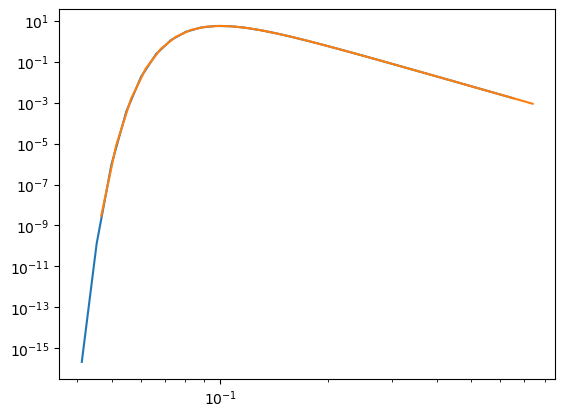

In [18]:
Sf_calc = np.trapz(spec_mod.efth[10, :, :].squeeze(), (np.pi/180)*spec_mod.direction, axis=1)
plt.loglog(f, Sf)
plt.loglog(spec_mod.frequency, Sf_calc)
print(4*np.sqrt(np.trapz(Sf, f)))
print(4*np.sqrt(np.trapz(Sf_calc, f)))

In [41]:
2.979/np.pi

0.9482451509415125

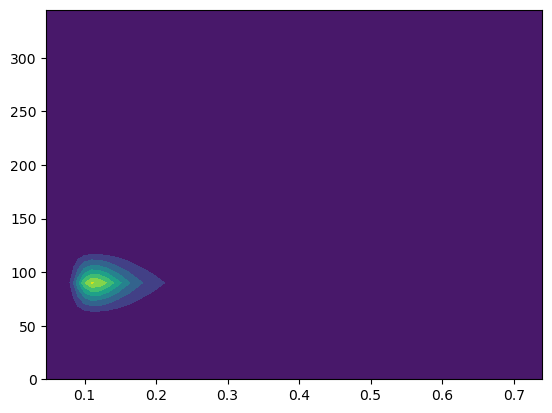

In [33]:
plt.contourf(spec_mod.frequency, spec_mod.direction, spec_mod.efth[10, :, :].squeeze().T)

In [69]:
spec ="/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/sample_spec.nc"
spec = xr.open_dataset(spec)
unsorted_dirs = spec.direction
spec = spec.sortby('direction')

In [78]:
spec = spec.reindex(direction=unsorted_dirs)
spec.direction

<xarray.DataArray 'direction' (direction: 24)>
array([ 90.,  75.,  60.,  45.,  30.,  15.,   0., 345., 330., 315., 300., 285.,
       270., 255., 240., 225., 210., 195., 180., 165., 150., 135., 120., 105.],
      dtype=float32)
Coordinates:
  * direction  (direction) float32 90.0 75.0 60.0 45.0 ... 135.0 120.0 105.0
Attributes:
    long_name:      sea surface wave to direction
    standard_name:  sea_surface_wave_to_direction
    globwave_name:  direction
    units:          degree
    valid_min:      0.0
    valid_max:      360.0
    axis:           Z

In [71]:
unsorted_dirs

<xarray.DataArray 'direction' (direction: 24)>
array([ 90.,  75.,  60.,  45.,  30.,  15.,   0., 345., 330., 315., 300., 285.,
       270., 255., 240., 225., 210., 195., 180., 165., 150., 135., 120., 105.],
      dtype=float32)
Coordinates:
  * direction  (direction) float32 90.0 75.0 60.0 45.0 ... 135.0 120.0 105.0
Attributes:
    long_name:      sea surface wave to direction
    standard_name:  sea_surface_wave_to_direction
    globwave_name:  direction
    units:          degree
    valid_min:      0.0
    valid_max:      360.0
    axis:           Z

In [ ]:
#modify the files for the BCs for a wide run

spec ="/Users/jamesstadler/Documents/UW/TFO/Code/ww3_docker/inertial_current_simulations/idealized_runs_wide_hyak/BCs/BC_5/"
spec = xr.open_dataset(spec)